<div style="background-color:#00843D;padding:22px 28px;border-radius:12px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales
  </p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 04: La Base de Datos MNIST
## Que significa aprender a clasificar imagenes

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Describir** la estructura y origen del dataset MNIST
2. **Explorar** los datos antes de entrenar cualquier modelo
3. **Explicar** que representa cada dimension del tensor de entrada
4. **Analizar** que aprende realmente una red neuronal al entrenar
5. **Preparar** el pipeline de datos para el Notebook 05

---

> Las celdas **[OK]** estan listas con `Shift+Enter`. Las **[Ejercicio]** son para completar.


## 1. MNIST: el dataset que cambio la historia

En 1998, Yann LeCun, Corinna Cortes y Christopher Burges publicaron **MNIST**
(*Modified National Institute of Standards and Technology*).

El dataset contiene **70,000 imagenes** de digitos escritos a mano (0 al 9),
recopiladas de empleados del censo de EE.UU. y estudiantes de secundaria.

| Subconjunto | Imagenes | Uso |
|-------------|----------|-----|
| Entrenamiento | 60,000 | Ajustar los pesos de la red |
| Prueba | 10,000 | Evaluar el modelo final |

Cada imagen: **28 x 28 pixeles**, escala de grises (0=negro, 255=blanco), y una etiqueta (0-9).

> **Su papel historico:** LeCun lo uso para demostrar las primeras **redes convolucionales**
> (LeNet, 1998). Durante mas de dos decadas fue el benchmark estandar de vision por
> computador. Hoy se considera "resuelto" (~99.8% de exactitud), pero sigue siendo
> el punto de entrada ideal para entender el aprendizaje profundo.


In [ ]:
# [OK] Cargar MNIST directamente desde TensorFlow

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})

VERDE = "#00843D"; AZUL = "#1a5fa8"; ROJO = "#c0392b"
NARANJA = "#e67e22"; MORADO = "#8e44ad"

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

print("Dataset MNIST cargado.")
print(f"  Entrenamiento: {X_train_raw.shape}  etiquetas: {y_train.shape}")
print(f"  Prueba:        {X_test_raw.shape}   etiquetas: {y_test.shape}")
print(f"  Rango de pixeles: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"  Clases: {sorted(set(y_train.tolist()))}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset MNIST cargado.
  Entrenamiento: (60000, 28, 28)  etiquetas: (60000,)
  Prueba:        (10000, 28, 28)   etiquetas: (10000,)
  Rango de pixeles: [0, 255]
  Clases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


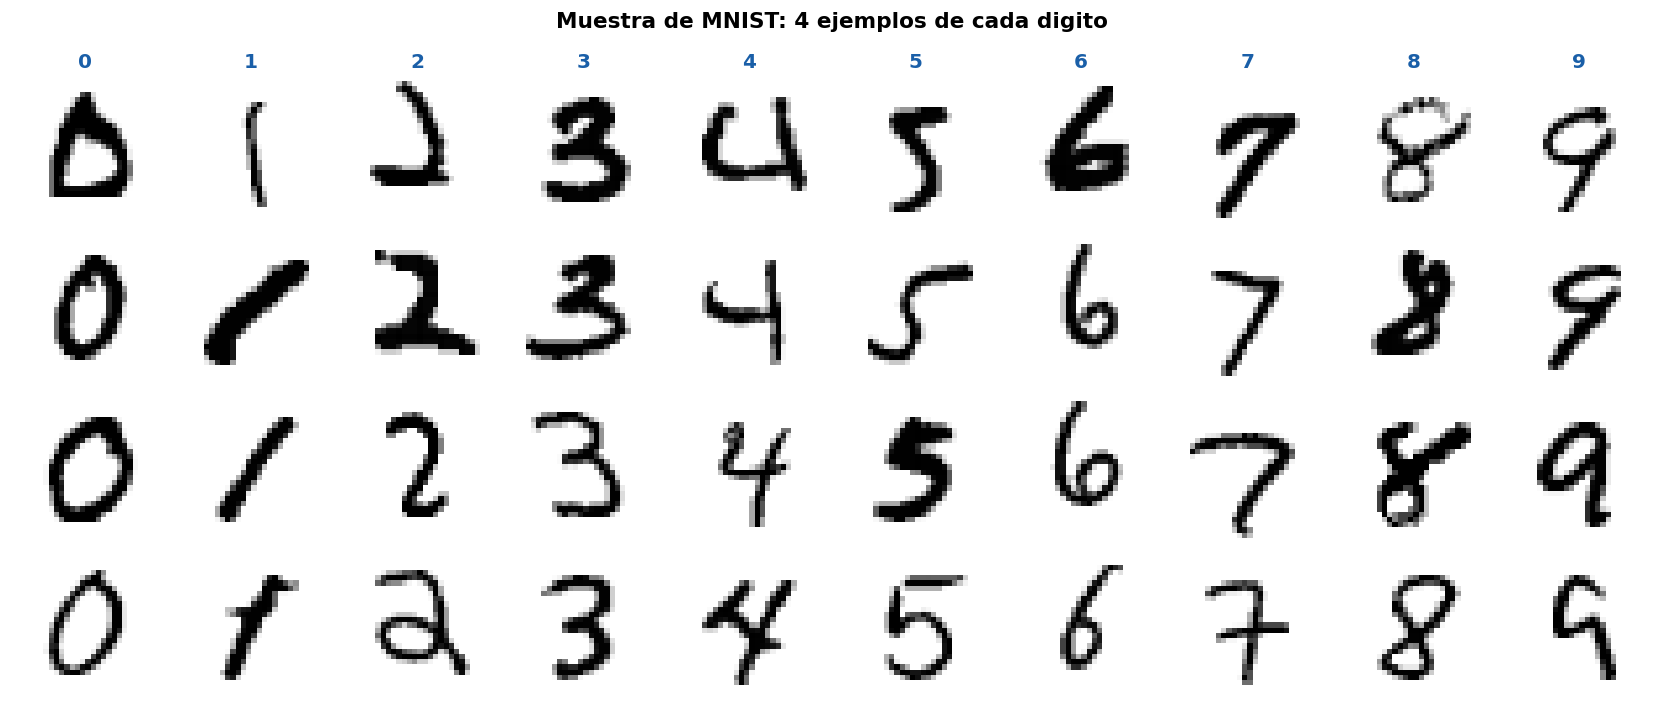

Observa la variabilidad: distintos estilos, inclinaciones, grosores.
La red debe generalizar sobre todas estas variaciones.


In [ ]:
# [OK] Visualizar una muestra del dataset: 4 ejemplos de cada digito

fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle("Muestra de MNIST: 4 ejemplos de cada digito",
             fontsize=13, fontweight="bold")

for digito in range(10):
    indices = np.where(y_train == digito)[0]
    muestra = np.random.choice(indices, 4, replace=False)
    for fila, idx in enumerate(muestra):
        ax = axes[fila, digito]
        ax.imshow(X_train_raw[idx], cmap="gray_r", interpolation="nearest")
        ax.axis("off")
        if fila == 0:
            ax.set_title(str(digito), fontsize=12, fontweight="bold", color=AZUL)

plt.tight_layout()
plt.show()

print("Observa la variabilidad: distintos estilos, inclinaciones, grosores.")
print("La red debe generalizar sobre todas estas variaciones.")


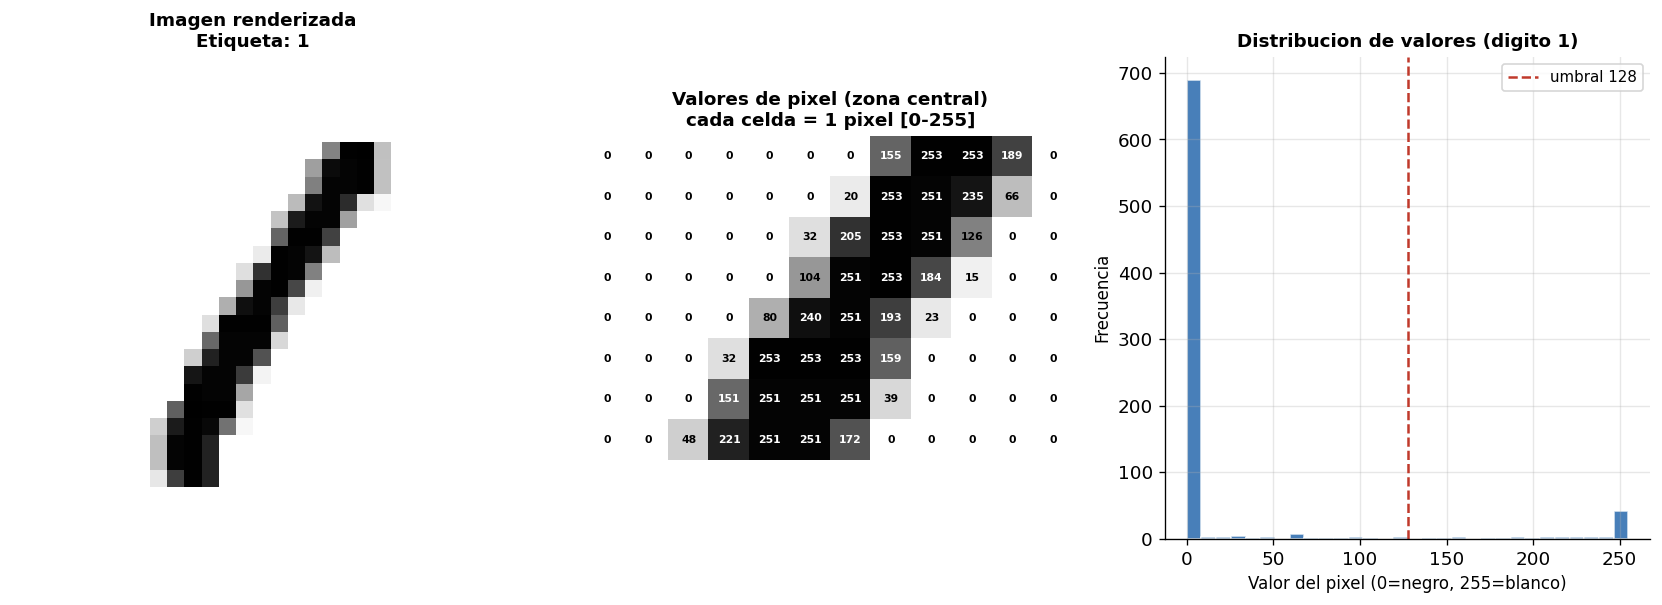

Forma de la imagen: (28, 28)  ->  784 pixeles totales
Pixeles en fondo (valor 0): 688 (87.8%)


In [ ]:
# [OK] Anatomia de una imagen MNIST: los valores de los pixeles

idx_ejemplo = 3
imagen = X_train_raw[idx_ejemplo]
etiqueta = y_train[idx_ejemplo]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. La imagen renderizada
axes[0].imshow(imagen, cmap="gray_r", interpolation="nearest")
axes[0].set_title(f"Imagen renderizada\nEtiqueta: {etiqueta}",
                  fontsize=11, fontweight="bold")
axes[0].axis("off")

# 2. Valores numericos de pixeles (zona central)
zona = imagen[10:18, 8:20]
axes[1].imshow(zona, cmap="gray_r", interpolation="nearest", vmin=0, vmax=255)
for i in range(zona.shape[0]):
    for j in range(zona.shape[1]):
        val = zona[i, j]
        ct = "white" if val > 128 else "black"
        axes[1].text(j, i, str(val), ha="center", va="center",
                     fontsize=6.5, color=ct, fontweight="bold")
axes[1].set_title("Valores de pixel (zona central)\ncada celda = 1 pixel [0-255]",
                  fontsize=11, fontweight="bold")
axes[1].axis("off")

# 3. Histograma
axes[2].hist(imagen.flatten(), bins=30, color=AZUL, alpha=0.8, edgecolor="white")
axes[2].axvline(128, color=ROJO, linewidth=1.5, linestyle="--", label="umbral 128")
axes[2].set_xlabel("Valor del pixel (0=negro, 255=blanco)", fontsize=10)
axes[2].set_ylabel("Frecuencia", fontsize=10)
axes[2].set_title(f"Distribucion de valores (digito {etiqueta})",
                  fontsize=11, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Forma de la imagen: {imagen.shape}  ->  {imagen.size} pixeles totales")
print(f"Pixeles en fondo (valor 0): {np.sum(imagen==0):,} ({np.mean(imagen==0):.1%})")


## 2. Preprocesamiento: preparar los datos para la red

Antes de entrenar, dos pasos obligatorios:

### Paso 1: Normalizar los pixeles

Los pixeles van de 0 a 255. Las redes funcionan mejor con entradas en $[0, 1]$:

$$x_{\text{norm}} = \frac{x}{255}$$

**Por que?** Si una entrada puede valer 255 y otra 0.5, los gradientes tendran
magnitudes muy distintas y el entrenamiento sera inestable.

### Paso 2: Entender la forma del tensor

El tensor de entrada tiene forma `(n, 28, 28)`:
- `n` = numero de muestras
- `28` = alto de la imagen en pixeles
- `28` = ancho de la imagen en pixeles

La capa `Flatten` lo convierte en `(n, 784)` antes de la primera capa densa.

> **Tensores:** en TensorFlow, un tensor es un array NumPy con seguimiento de gradientes.
> Las operaciones entre tensores pueden diferenciarse automaticamente -- eso es lo que
> hace posible backpropagation sin derivar nada a mano.


In [ ]:
# [Ejercicio 1] Preprocesar el dataset MNIST

# ================================================
# Completa los dos pasos:
# Paso 1: divide X_train_raw y X_test_raw por 255
#         y convierte a float32
# ================================================

X_train = X_train_raw.astype("float32") / 255.0   # <- X_train_raw.astype("float32") / 255.0
X_test  = X_test_raw.astype("float32") / 255.0   # <- X_test_raw.astype("float32")  / 255.0

if X_train is not None:
    print(f"Forma:  {X_train.shape}")
    print(f"Tipo:   {X_train.dtype}")
    print(f"Rango:  [{X_train.min():.3f}, {X_train.max():.3f}]")
    if X_train.max() <= 1.0 and X_train.dtype == np.float32:
        print("[OK] Normalizacion correcta.")
    else:
        print("[!] Revisa: rango debe ser [0,1] y tipo float32.")
else:
    print("[!] X_train es None -- completa el ejercicio.")


Forma:  (60000, 28, 28)
Tipo:   float32
Rango:  [0.000, 1.000]
[OK] Normalizacion correcta.


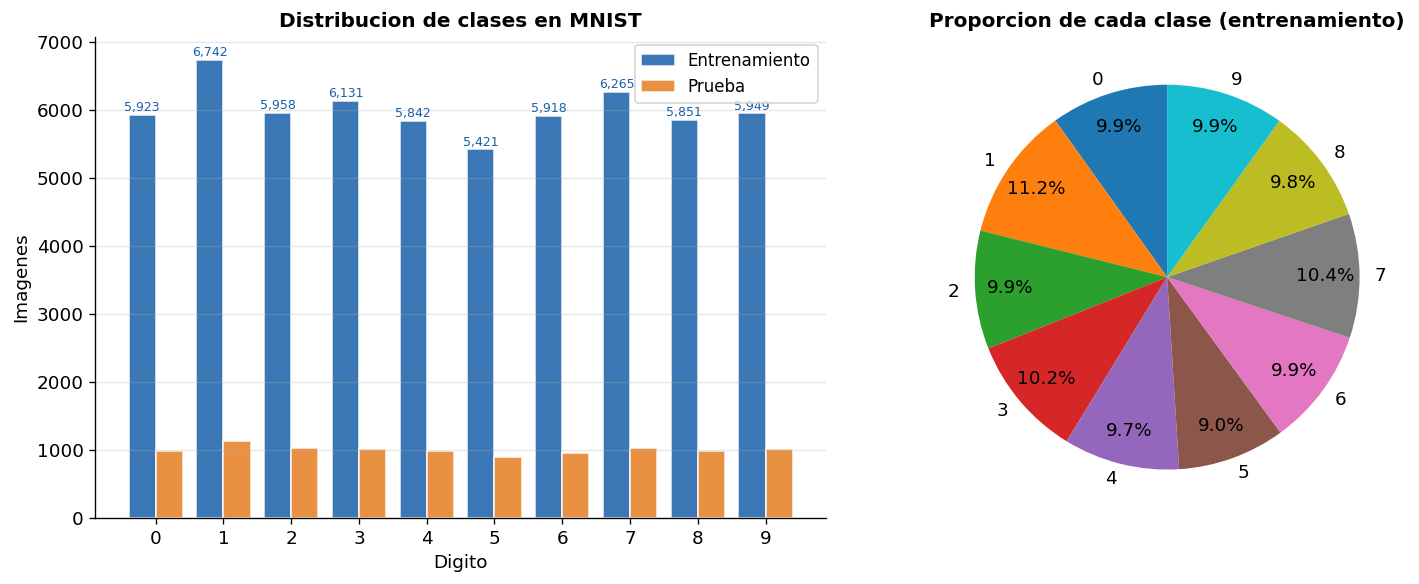

Dataset bien balanceado: ~10% por clase.
Un clasificador que siempre predice el mismo digito: ~10% de exactitud.
Esa es nuestra linea base (baseline) -- la red debe superarla ampliamente.


In [ ]:
# [OK] Explorar la distribucion de clases

# Fallback por si el Ejercicio 1 no esta completo
if X_train is None:
    X_train = X_train_raw.astype("float32") / 255.0
    X_test  = X_test_raw.astype("float32")  / 255.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conteos_train = [np.sum(y_train == d) for d in range(10)]
conteos_test  = [np.sum(y_test  == d) for d in range(10)]
x_pos = np.arange(10); width = 0.4

bars1 = axes[0].bar(x_pos - width/2, conteos_train, width,
                     label="Entrenamiento", color=AZUL, alpha=0.85, edgecolor="white")
bars2 = axes[0].bar(x_pos + width/2, conteos_test, width,
                     label="Prueba", color=NARANJA, alpha=0.85, edgecolor="white")
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f"{bar.get_height():,}", ha="center", fontsize=7.5, color=AZUL)
axes[0].set_xlabel("Digito", fontsize=11); axes[0].set_ylabel("Imagenes", fontsize=11)
axes[0].set_title("Distribucion de clases en MNIST", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(10)); axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis="y")

porcs = [c/sum(conteos_train)*100 for c in conteos_train]
axes[1].pie(porcs, labels=[str(d) for d in range(10)], autopct="%1.1f%%",
             startangle=90, colors=plt.cm.tab10(np.linspace(0, 1, 10)),
             pctdistance=0.82, labeldistance=1.08)
axes[1].set_title("Proporcion de cada clase (entrenamiento)",
                   fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

print("Dataset bien balanceado: ~10% por clase.")
print("Un clasificador que siempre predice el mismo digito: ~10% de exactitud.")
print("Esa es nuestra linea base (baseline) -- la red debe superarla ampliamente.")


## 3. Que aprende realmente una red al entrenar en MNIST?

Esta es la pregunta mas importante de este notebook.

Cuando la red clasifica un "3", no tiene ningun concepto del numero tres.
Lo que aprende son **patrones estadisticos en los pixeles** que correlacionan
con la etiqueta. Concretamente:

**Primera capa** (mas cercana a la entrada): detectores de bordes y trazos simples

**Capas intermedias**: combinaciones de detectores basicos en estructuras complejas

**Capa de salida**: asigna probabilidades segun todos los patrones previos

La red no *sabe* que es un "3". Solo sabe que cierta combinacion de activaciones
predice fuertemente la etiqueta 3.

> **Implicacion clave:** si le muestras imagenes de perros a esta red,
> predecira alguno de los digitos 0-9 con total confianza.
> No puede decir "esto no es ninguno de los digitos que conozco".
> Esa limitacion (problema de **distribucion fuera del dominio**)
> es un area activa de investigacion en IA.


In [ ]:
# [OK] Definir y entrenar la red MLP sobre MNIST

tf.random.set_seed(42)
modelo = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64,  activation="relu"),
    keras.layers.Dense(10,  activation="softmax"),
], name="MLP_MNIST")

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()
print()

historia = modelo.fit(
    X_train, y_train,
    epochs=12,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9001 - loss: 0.3529 - val_accuracy: 0.9607 - val_loss: 0.1415
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9577 - loss: 0.1467 - val_accuracy: 0.9693 - val_loss: 0.1055
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9694 - loss: 0.1038 - val_accuracy: 0.9720 - val_loss: 0.0983
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9772 - loss: 0.0776 - val_accuracy: 0.9720 - val_loss: 0.0928
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9825 - loss: 0.0596 - val_accuracy: 0.9725 - val_loss: 0.0917
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9870 - loss: 0.0465 - val_accuracy: 0.9730 - val_loss: 0.0930
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9898 - loss: 0.0364 - val_accuracy: 0.9718 - val_loss: 0.1005
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9922 - loss: 0.0292 - val_accuracy: 0

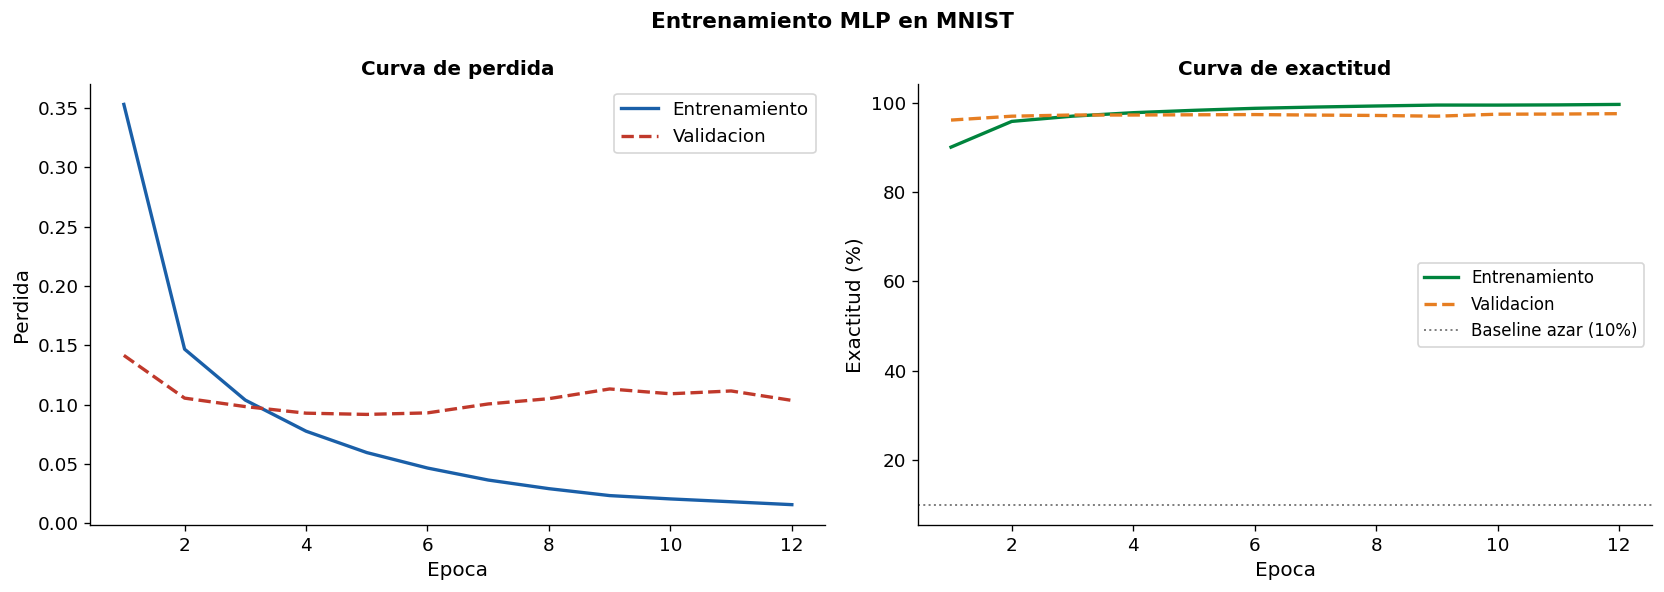

Resultado en TEST SET (10,000 imagenes nunca vistas):
  Exactitud: 0.9724  (97.24%)
  Errores:   275 de 10,000 imagenes


In [ ]:
# [OK] Curvas de aprendizaje y evaluacion final en test set

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, len(historia.history["loss"]) + 1)

axes[0].plot(epocas, historia.history["loss"],     color=AZUL, linewidth=2, label="Entrenamiento")
axes[0].plot(epocas, historia.history["val_loss"], color=ROJO, linewidth=2,
             linestyle="--", label="Validacion")
axes[0].set_xlabel("Epoca", fontsize=12); axes[0].set_ylabel("Perdida", fontsize=12)
axes[0].set_title("Curva de perdida", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=11)

acc_tr  = [v*100 for v in historia.history["accuracy"]]
acc_val = [v*100 for v in historia.history["val_accuracy"]]
axes[1].plot(epocas, acc_tr,  color=VERDE,  linewidth=2, label="Entrenamiento")
axes[1].plot(epocas, acc_val, color=NARANJA, linewidth=2, linestyle="--", label="Validacion")
axes[1].axhline(10, color="gray", linewidth=1.2, linestyle=":", label="Baseline azar (10%)")
axes[1].set_xlabel("Epoca", fontsize=12); axes[1].set_ylabel("Exactitud (%)", fontsize=12)
axes[1].set_title("Curva de exactitud", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)

plt.suptitle("Entrenamiento MLP en MNIST", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

loss_test, acc_test = modelo.evaluate(X_test, y_test, verbose=0)
print(f"Resultado en TEST SET (10,000 imagenes nunca vistas):")
print(f"  Exactitud: {acc_test:.4f}  ({acc_test*100:.2f}%)")
print(f"  Errores:   {int((1-acc_test)*10000):,} de 10,000 imagenes")


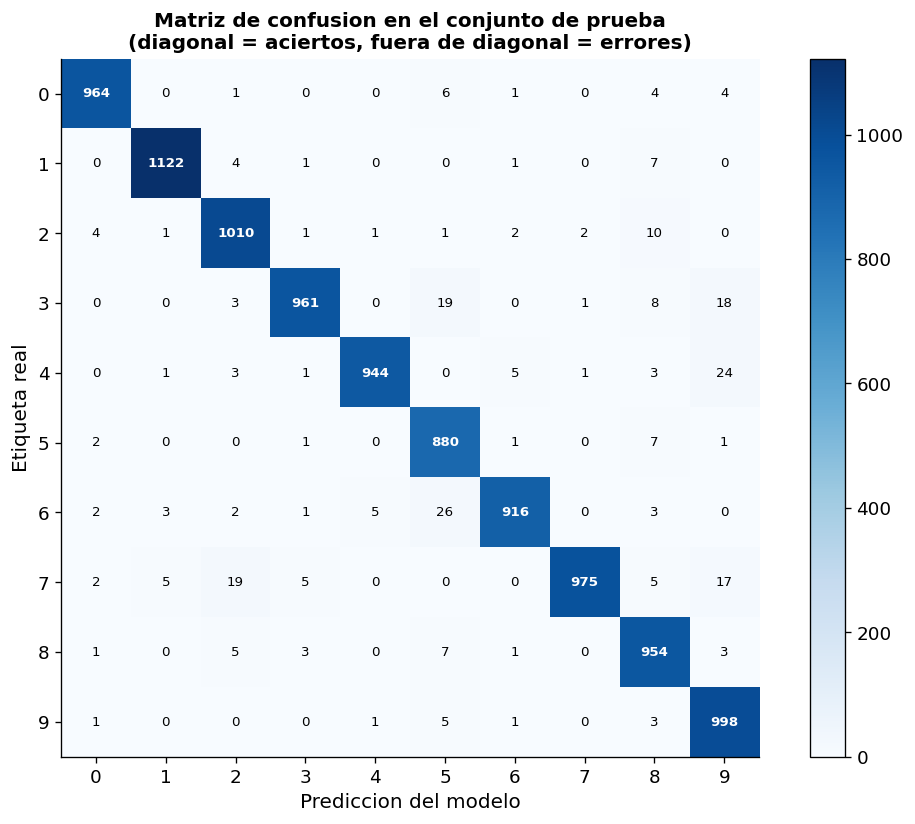

Par mas confundido: real=6 predicho=5  (26 casos)
Los errores suelen ocurrir entre digitos visualmente similares (4-9, 3-8, 1-7).


In [ ]:
# [OK] Matriz de confusion: donde se equivoca la red

y_pred = np.argmax(modelo.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
plt.colorbar(im, ax=ax)

for i in range(10):
    for j in range(10):
        val = cm[i, j]
        color = "white" if val > cm.max()/2 else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=8, color=color,
                fontweight="bold" if i == j else "normal")

ax.set_xticks(range(10)); ax.set_xticklabels(range(10))
ax.set_yticks(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel("Prediccion del modelo", fontsize=12)
ax.set_ylabel("Etiqueta real", fontsize=12)
ax.set_title("Matriz de confusion en el conjunto de prueba\n"
             "(diagonal = aciertos, fuera de diagonal = errores)",
             fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

cm_nd = cm.copy(); np.fill_diagonal(cm_nd, 0)
idx_max = np.unravel_index(np.argmax(cm_nd), cm_nd.shape)
print(f"Par mas confundido: real={idx_max[0]} predicho={idx_max[1]}  ({cm[idx_max]} casos)")
print("Los errores suelen ocurrir entre digitos visualmente similares (4-9, 3-8, 1-7).")


Total de errores en test: 276 de 10000


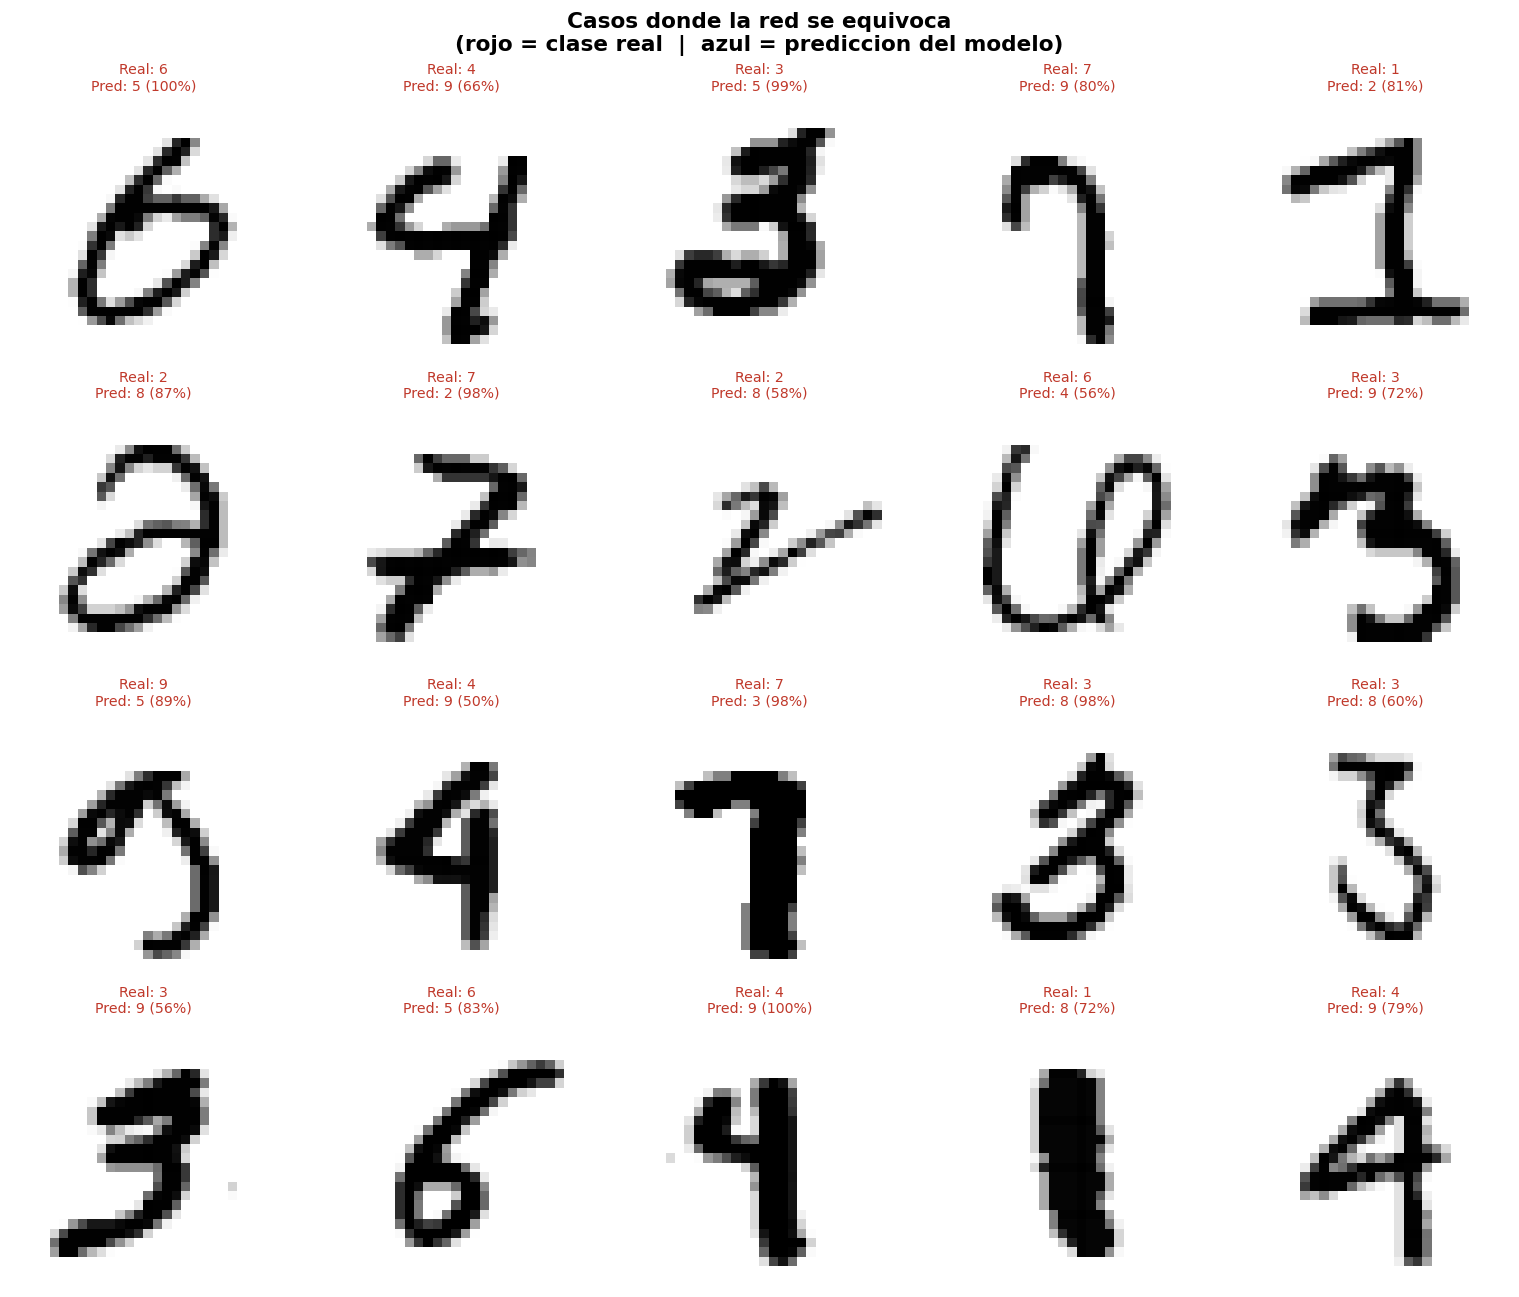

En muchos errores, incluso un humano dudaria.


In [ ]:
# [OK] Ver los casos donde la red se equivoca

errores_idx = np.where(y_pred != y_test)[0]
print(f"Total de errores en test: {len(errores_idx)} de {len(y_test)}")

np.random.seed(7)
muestra_err = np.random.choice(errores_idx, 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(13, 11))
fig.suptitle("Casos donde la red se equivoca\n"
             "(rojo = clase real  |  azul = prediccion del modelo)",
             fontsize=13, fontweight="bold")

for ax, idx in zip(axes.flat, muestra_err):
    ax.imshow(X_test[idx], cmap="gray_r", interpolation="nearest")
    ax.axis("off")
    real = y_test[idx]; pred = y_pred[idx]
    probs = modelo.predict(X_test[idx:idx+1], verbose=0)[0]
    confianza = probs[pred]
    ax.set_title(f"Real: {real}\nPred: {pred} ({confianza:.0%})",
                 fontsize=8.5, color=ROJO)

plt.tight_layout(); plt.show()

print("En muchos errores, incluso un humano dudaria.")


Confianza media aciertos: 0.991
Confianza media errores:  0.776


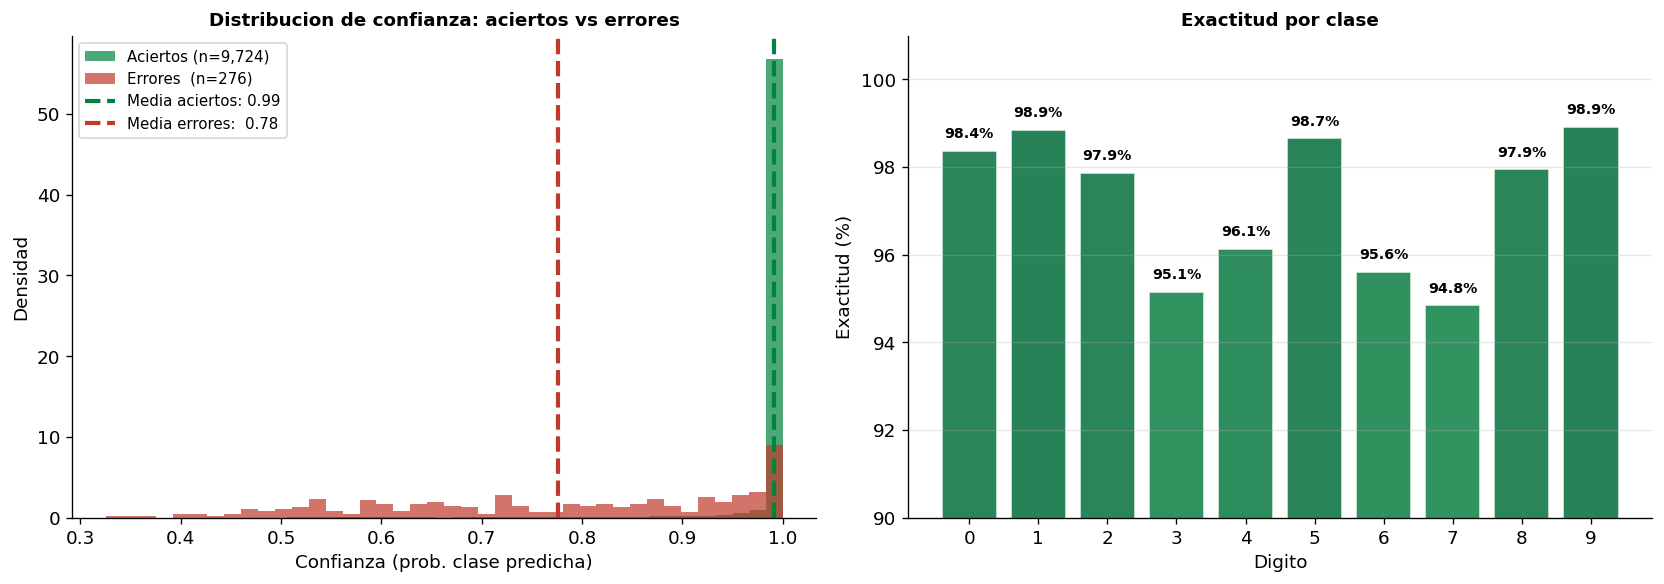

In [ ]:
# [Ejercicio 2] Analizar la confianza del modelo en aciertos vs errores

probs_test = modelo.predict(X_test, verbose=0)
confianza_pred = np.max(probs_test, axis=1)
aciertos = y_pred == y_test
conf_ok  = confianza_pred[aciertos]
conf_err = confianza_pred[~aciertos]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(conf_ok,  bins=40, color=VERDE, alpha=0.7,
             label=f"Aciertos (n={aciertos.sum():,})", density=True)
axes[0].hist(conf_err, bins=40, color=ROJO,  alpha=0.7,
             label=f"Errores  (n={(~aciertos).sum():,})", density=True)
axes[0].set_xlabel("Confianza (prob. clase predicha)", fontsize=11)
axes[0].set_ylabel("Densidad", fontsize=11)
axes[0].set_title("Distribucion de confianza: aciertos vs errores",
                   fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10)

# ================================================
# [Ejercicio] Calcula la confianza media
# en aciertos y en errores.
# Luego agrega lineas verticales en el histograma.
# ================================================
media_ok  = np.mean(conf_ok)   # <- np.mean(conf_ok)
media_err = np.mean(conf_err)   # <- np.mean(conf_err)

if media_ok is not None:
    axes[0].axvline(media_ok,  color=VERDE, lw=2.5, linestyle="--",
                    label=f"Media aciertos: {media_ok:.2f}")
    axes[0].axvline(media_err, color=ROJO,  lw=2.5, linestyle="--",
                    label=f"Media errores:  {media_err:.2f}")
    axes[0].legend(fontsize=9)
    print(f"Confianza media aciertos: {media_ok:.3f}")
    print(f"Confianza media errores:  {media_err:.3f}")

# Exactitud por clase
acc_por_clase = [(y_pred[y_test==d] == d).mean() for d in range(10)]
axes[1].bar(range(10), [a*100 for a in acc_por_clase],
             color=[plt.cm.RdYlGn(a) for a in acc_por_clase],
             alpha=0.85, edgecolor="white")
for d in range(10):
    axes[1].text(d, acc_por_clase[d]*100 + 0.3, f"{acc_por_clase[d]:.1%}",
                 ha="center", fontsize=8.5, fontweight="bold")
axes[1].set_xlabel("Digito", fontsize=11); axes[1].set_ylabel("Exactitud (%)", fontsize=11)
axes[1].set_title("Exactitud por clase", fontsize=11, fontweight="bold")
axes[1].set_xticks(range(10)); axes[1].set_ylim(90, 101)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


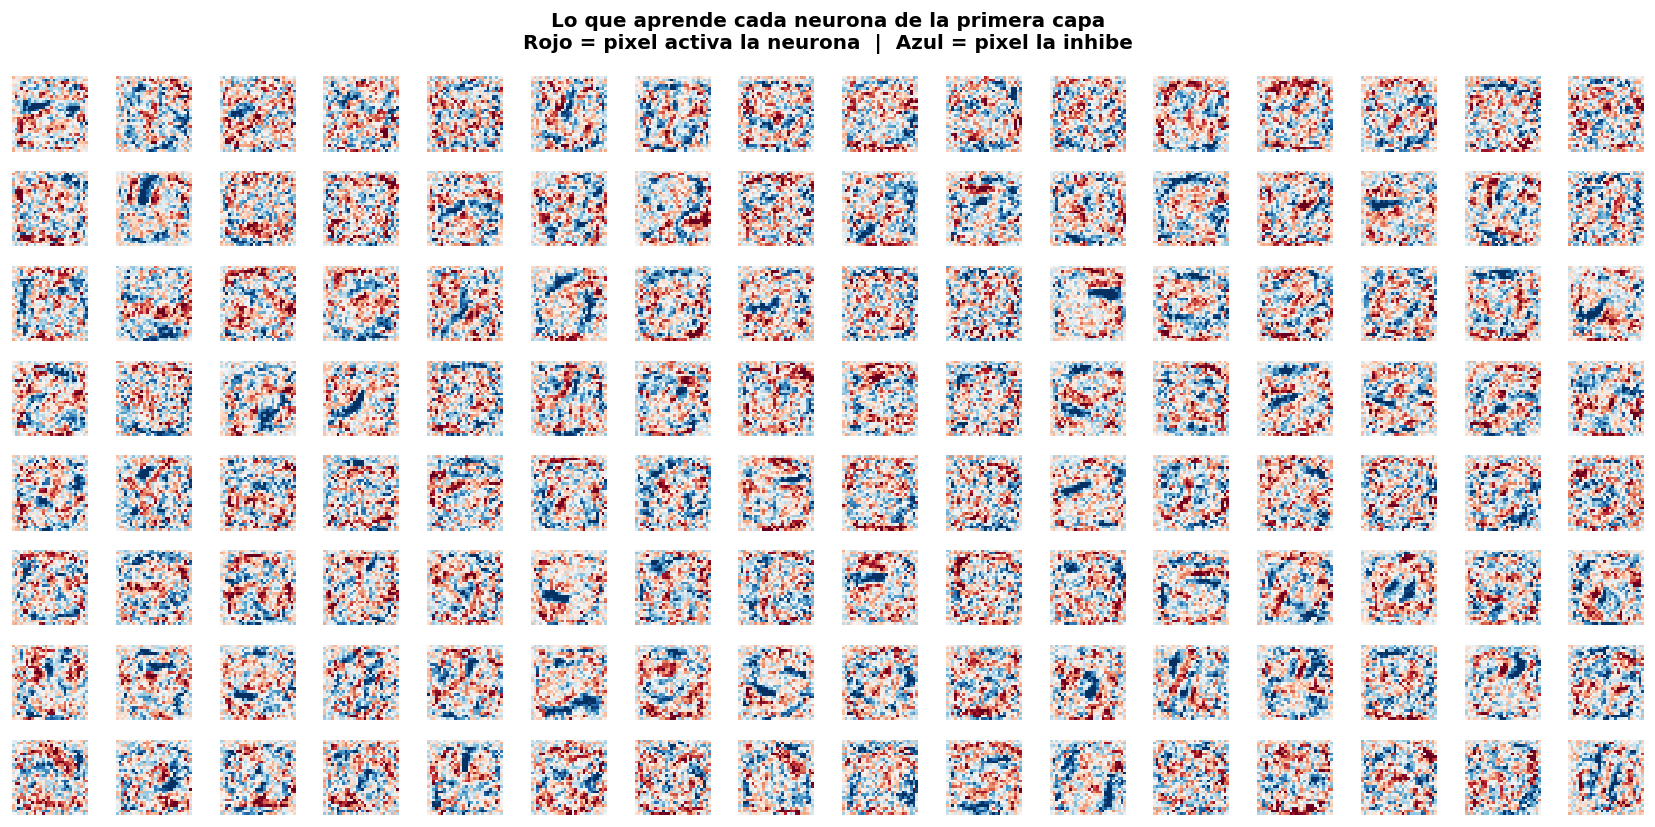

Cada recuadro es el perfil de una neurona: las zonas rojas son los
pixeles que la activan, y las azules los que la inhiben.
Esto emerge automaticamente del entrenamiento -- nadie lo programo.


In [ ]:
# [OK] Visualizar lo que aprende la primera capa: sus pesos como imagenes 28x28

W1 = modelo.layers[1].get_weights()[0]  # forma: (784, 128)
W1 = W1.T                                # -> (128, 784)

fig, axes = plt.subplots(8, 16, figsize=(14, 7))
fig.suptitle("Lo que aprende cada neurona de la primera capa\n"
             "Rojo = pixel activa la neurona  |  Azul = pixel la inhibe",
             fontsize=12, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i < W1.shape[0]:
        filtro = W1[i].reshape(28, 28)
        ax.imshow(filtro, cmap="RdBu_r", interpolation="nearest",
                  vmin=-filtro.std()*2, vmax=filtro.std()*2)
    ax.axis("off")

plt.tight_layout(); plt.show()

print("Cada recuadro es el perfil de una neurona: las zonas rojas son los")
print("pixeles que la activan, y las azules los que la inhiben.")
print("Esto emerge automaticamente del entrenamiento -- nadie lo programo.")


--- Ejemplo de ACIERTO ---


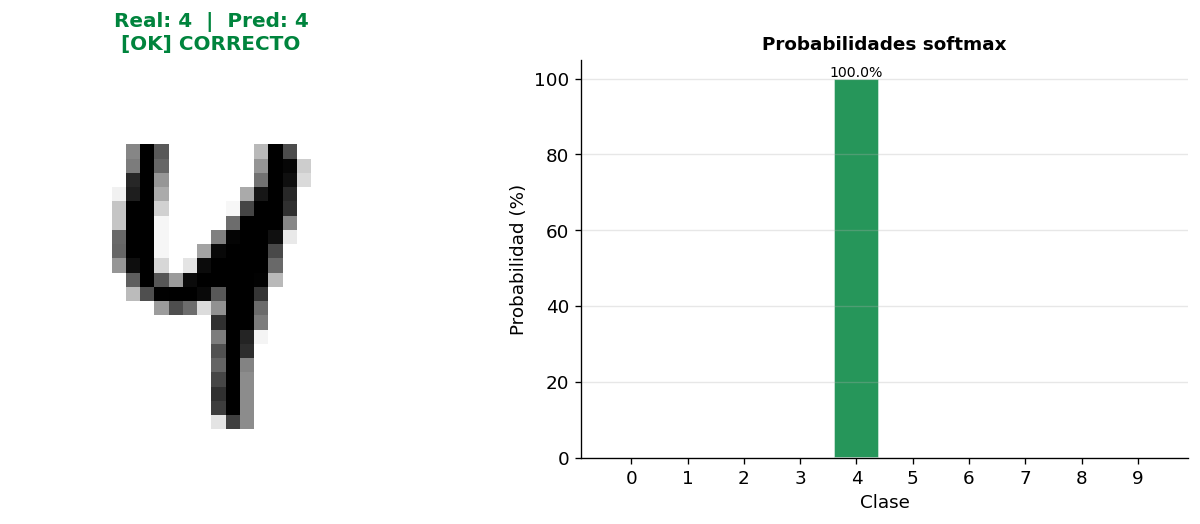

--- Ejemplo de ERROR ---


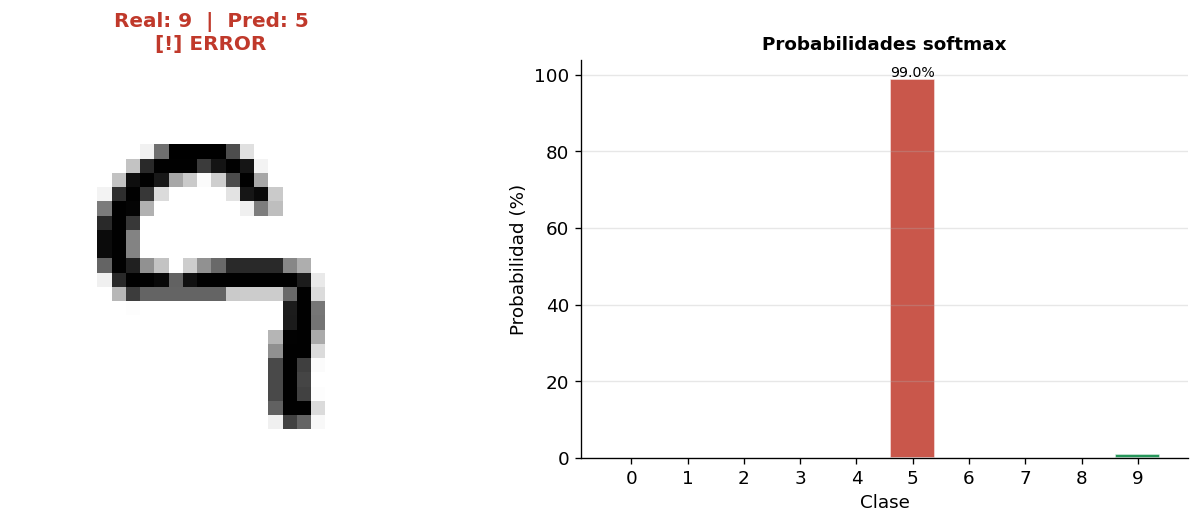

In [ ]:
# [OK] Explorar predicciones individuales del modelo

def analizar_prediccion(idx, X=X_test, y=y_test):
    img = X[idx]; etiqueta = y[idx]
    probs = modelo.predict(img[np.newaxis], verbose=0)[0]
    pred  = np.argmax(probs)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].imshow(img, cmap="gray_r", interpolation="nearest")
    color_t = VERDE if pred == etiqueta else ROJO
    estado  = "[OK] CORRECTO" if pred == etiqueta else "[!] ERROR"
    axes[0].set_title(f"Real: {etiqueta}  |  Pred: {pred}\n{estado}",
                       fontsize=12, fontweight="bold", color=color_t)
    axes[0].axis("off")

    colores = [VERDE if d == etiqueta else (ROJO if d == pred else "#aaa") for d in range(10)]
    bars = axes[1].bar(range(10), probs*100, color=colores, alpha=0.85, edgecolor="white")
    for bar, p in zip(bars, probs):
        if p > 0.01:
            axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                          f"{p:.1%}", ha="center", fontsize=8.5)
    axes[1].set_xlabel("Clase", fontsize=11); axes[1].set_ylabel("Probabilidad (%)", fontsize=11)
    axes[1].set_title("Probabilidades softmax", fontsize=11, fontweight="bold")
    axes[1].set_xticks(range(10))
    axes[1].grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

print("--- Ejemplo de ACIERTO ---")
idx_ok = np.where(y_pred == y_test)[0][42]
analizar_prediccion(idx_ok)

print("--- Ejemplo de ERROR ---")
analizar_prediccion(errores_idx[0])


In [ ]:
# [OK] Preparar el pipeline para el Notebook 05
# El NB05 reproducira la Tabla 1 del paper Chen et al. 2018.

def preparar_mnist_paper():
    (Xtr, ytr), (Xte, yte) = keras.datasets.mnist.load_data()
    Xtr = Xtr.astype("float32") / 255.0
    Xte = Xte.astype("float32") / 255.0
    Xtr_flat = Xtr.reshape(-1, 784)
    Xte_flat = Xte.reshape(-1, 784)
    return (Xtr, ytr), (Xte, yte), (Xtr_flat, ytr), (Xte_flat, yte)

(X_tr2d, y_tr2d), (X_te2d, y_te2d), (X_tr1d, y_tr1d), (X_te1d, y_te1d) = preparar_mnist_paper()

print("Pipeline listo para el Notebook 05:")
print(f"  2D (conv / flatten): X_train {X_tr2d.shape}  X_test {X_te2d.shape}")
print(f"  1D (MLP directo):    X_train {X_tr1d.shape}  X_test {X_te1d.shape}")
print()
print("En el NB05 usaremos estos datos para reproducir la Tabla 1 del paper:")
print("  MLP vs ResNet vs RK-Net en MNIST -- los tres modelos sobre los mismos datos.")


Pipeline listo para el Notebook 05:
  2D (conv / flatten): X_train (60000, 28, 28)  X_test (10000, 28, 28)
  1D (MLP directo):    X_train (60000, 784)  X_test (10000, 784)

En el NB05 usaremos estos datos para reproducir la Tabla 1 del paper:
  MLP vs ResNet vs RK-Net en MNIST -- los tres modelos sobre los mismos datos.


## 4. Resumen y puente hacia el Notebook 05

### Lo que aprendimos

| Concepto | Lo que aprendimos |
|----------|------------------|
| **MNIST** | 70,000 imagenes etiquetadas de digitos escritos a mano |
| **Tensor de entrada** | `(n, 28, 28)`: n muestras de imagenes 28x28 |
| **Normalizacion** | Dividir por 255 para pixeles en [0, 1] |
| **Baseline** | Clasificador aleatorio: ~10%; nuestra red supera 97% |
| **Matriz de confusion** | Muestra que pares de clases confunde el modelo |
| **Confianza softmax** | Alta en aciertos, mas baja en errores |
| **Pesos de primera capa** | Cada neurona aprende un detector de patron visual |

---

### La cadena completa que hemos recorrido

```
Neurona biologica (NB01)      sistema dinamico, EDOs, RK4
        |
        v  abstraccion McCulloch-Pitts
Perceptron (NB02)             suma ponderada + umbral
        |
        v  capas + backpropagation
Red neuronal densa (NB03)     gradiente, activaciones, Keras
        |
        v  datos reales
MNIST (NB04)                  97%+ de exactitud
        |
        v  volver a las raices: EDOs + redes
Neural ODEs (NB05)            Chen et al. 2018
```

El Notebook 05 cierra el circulo: reproduce los resultados del paper
que une los metodos numericos para EDOs con las redes neuronales profundas.

---

### Siguiente: Notebook 05 -- Del Paper a la Implementacion

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
